In [ ]:
!gcloud auth application-default login

In [1]:
import os

import hail as hl
import numpy as np
import pyspark.sql.functions as f
from pyspark.sql import DataFrame

from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.summary_statistics import SummaryStatistics
from gentropy.dataset.study_locus import StudyLocus
from gentropy.susie_finemapper import SusieFineMapperStep
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment

"""Common utilities for the project."""

import os
from pathlib import Path
from gentropy.common.session import Session
import logging


def get_gcs_credentials() -> str:
    """Get the credentials for google cloud storage."""
    app_default_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/application_default_credentials.json"
    )

    service_account_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/service_account_credentials.json"
    )

    if Path(app_default_credentials).exists():
        return app_default_credentials
    else:
        raise FileNotFoundError("No GCS credentials found.")


def get_gcs_hadoop_connector_jar() -> str:
    """Get the google cloud storage hadoop connector for spark.

    This function will return the url to download the hadoop jar.
    """

    return (
        "https://storage.googleapis.com/hadoop-lib/gcs/gcs-connector-hadoop3-latest.jar"
    )


def gcs_conf(
    credentials_path=None, project="open-targets-genetics-dev"
) -> dict[str, str]:
    """Get the spark configuration with hadoop connector for google cloud storage."""
    credentials_path = credentials_path or get_gcs_credentials()
    return {
        "spark.driver.memory": "12g",
        "spark.kryoserializer.buffer.max": "500m",
        "spark.driver.maxResultSize":"2g",
        "spark.hadoop.fs.gs.impl": "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem",
        "spark.jars": get_gcs_hadoop_connector_jar(),
        "spark.hadoop.google.cloud.auth.service.account.enable": "true",
        "spark.hadoop.fs.gs.project.id": project,
        "spark.hadoop.google.cloud.auth.service.account.json.keyfile": credentials_path,
        "spark.hadoop.fs.gs.requester.pays.mode": "AUTO",
    }


class GentropySession(Session):
    def __init__(self, *args, **kwargs):
        if "extended_spark_conf" in kwargs:
            kwargs["extended_spark_conf"].update(gcs_conf())
        else:
            kwargs["extended_spark_conf"] = gcs_conf()
        super().__init__(*args, **kwargs)

    @property
    def conf(self):
        logging.warning(
            "To change the config restart the session and use the `extended_spark_conf` parameter."
        )
        return self.spark.sparkContext.getConf().getAll()

session= GentropySession()


Loading BokehJS ...

/Users/yt4/Projects/gentropy/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/14 10:51:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/10/14 10:51:23 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [2]:
path_to_release_folder="gs://open-targets-data-releases/25.06/"


si=StudyIndex.from_parquet(session,path_to_release_folder+"output/study/")
sl=StudyLocus.from_parquet(session,path_to_release_folder+"output/credible_set/")

sl_eff=session.spark.read.parquet("gs://genetics-portal-dev-analysis/ss60/gentropy-manuscript/chapters/variant-effect-prediction/25.07/lead_variant_effect")

l2g_full=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS.parquet")

In [3]:
l2g_full=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/l2g_full_for_enrichment")
l2g_full.count()

70400

In [4]:
PSs=session.spark.read.csv("/Users/yt4/Desktop/PSs/genes_with_residuals.csv",header=True)

In [5]:
PSs.show(1)

+---------------+--------------+--------------+----------------------+------------+------------+------+--------------+----------------------+----------------------+-----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+------------+--------------+-------------+-------------+-------------+------------+----------+-----------------+------------------+--------+----------------------+------------------------------+-------------------------------+
|         geneId|uniqueVariants|uniqueDisease

25/10/14 10:51:36 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [6]:
PSs.count()

8285

In [7]:
FSs=session.spark.read.parquet("/Users/yt4/Desktop/PSs/list_of_prioritised_genes_with_FS.parquet")
FSs.show(1)

+---------------+-----------------------------+--------------------+-----------------------+
|         geneId|sum_weighted_sum_beta_variant|sum_sum_beta_variant|count_variants_per_gene|
+---------------+-----------------------------+--------------------+-----------------------+
|ENSG00000126653|           0.5645239416468776|  0.7745972009678808|                      4|
+---------------+-----------------------------+--------------------+-----------------------+
only showing top 1 row



In [8]:
FSs.count()

8285

In [9]:
PSs=PSs.join(FSs,"geneId","inner").cache()
PSs.count()

8285

In [11]:
PSs.show(5)

+---------------+--------------+--------------+----------------------+------------+------------+------+--------------+----------------------+----------------------+-----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+------------+--------------+-------------+-------------+-------------+------------+----------+-----------------+------------------+--------+----------------------+------------------------------+-------------------------------+-----------------------------+----------------

In [12]:
# Method 1: Convert to Pandas and use corr()
correlation_columns = [
    "sum_weighted_sum_beta_variant", 
    "sum_sum_beta_variant", 
    "uniqueVariants", 
    "uniqueDiseases", 
    "uniqueTherapeuticAreas"
]

# Convert to Pandas DataFrame with only the columns of interest
ps_pandas = PSs.select(*correlation_columns).toPandas()

# Calculate correlation matrix
correlation_matrix = ps_pandas.corr()
print("Correlation Matrix:")
print(correlation_matrix)

# Display with better formatting
correlation_matrix.round(3)

Correlation Matrix:
                               sum_weighted_sum_beta_variant  \
sum_weighted_sum_beta_variant                       1.000000   
sum_sum_beta_variant                                0.993293   
uniqueVariants                                      0.644587   
uniqueDiseases                                      0.697633   
uniqueTherapeuticAreas                              0.526609   

                               sum_sum_beta_variant  uniqueVariants  \
sum_weighted_sum_beta_variant              0.993293        0.644587   
sum_sum_beta_variant                       1.000000        0.659071   
uniqueVariants                             0.659071        1.000000   
uniqueDiseases                             0.706981        0.830754   
uniqueTherapeuticAreas                     0.545779        0.766293   

                               uniqueDiseases  uniqueTherapeuticAreas  
sum_weighted_sum_beta_variant        0.697633                0.526609  
sum_sum_beta_variant    

,sum_weighted_sum_beta_variant,sum_sum_beta_variant,uniqueVariants,uniqueDiseases,uniqueTherapeuticAreas
sum_weighted_sum_beta_variant,1.000,0.993,0.645,0.698,0.527
sum_sum_beta_variant,0.993,1.000,0.659,0.707,0.546
uniqueVariants,0.645,0.659,1.000,0.831,0.766
uniqueDiseases,0.698,0.707,0.831,1.000,0.845
uniqueTherapeuticAreas,0.527,0.546,0.766,0.845,1.000


In [13]:
l2g_full.show(1)

+--------------------+--------------------+---------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+
|        studyLocusId|             studyId|         geneId|            score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                 maf|     variantId|year|is_nfe|     diseaseIds|nfe_common|non_nfe_common|rare|           absBeta|
+--------------------+--------------------+---------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+
|cd9dd38e1f85a069d...|FINNGEN_R12_H7_IR...|ENSG00000152954|0.344258189201355|         0|         0|  0|          1|0.029878971255673223|6_23867964_T_C|2024|     0|[MONDO_0004773]|         0|             1|   0|0.4207366138701276|
+--------------------+--------------------+---------------+-----------------+---

In [14]:
PSs.show(1)

+---------------+--------------+--------------+----------------------+------------+------------+------+--------------+----------------------+----------------------+-----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+------------+--------------+-------------+-------------+-------------+------------+----------+-----------------+------------------+--------+----------------------+------------------------------+-------------------------------+-----------------------------+----------------

In [22]:
print(range(1, 11))

range(1, 11)


In [23]:
disease_index_path=path_to_release_folder+"output/disease/disease.parquet"
disease_index_orig = session.spark.read.parquet(disease_index_path)

platform_chembl_evidence_path=path_to_release_folder+"output/evidence/sourceId=chembl"
chembl_evidence=session.spark.read.parquet(platform_chembl_evidence_path)

In [24]:
efo_to_remove = (
    chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
        disease_index_orig=disease_index_orig,
        efo_ids="MONDO_0045024",
    )
)

In [25]:
import pandas as pd
all_enrich = []
ps_priv=1
for ps_score in range(1, 11):
    if ps_score==1:
        PSs_filtered = PSs.filter(f.col("uniqueDiseases") == ps_score).select("geneId").distinct()
    elif ps_score==10:
        PSs_filtered = PSs.filter(f.col("uniqueDiseases") >= ps_score).select("geneId").distinct()
    else:
        PSs_filtered = PSs.filter((f.col("uniqueDiseases") > ps_priv)&(f.col("uniqueDiseases") <= ps_score)).select("geneId").distinct()
        ps_priv = ps_score

    evidence=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=l2g_full.join(PSs_filtered, "geneId","inner").drop("diseaseIds"),
        score_column="score",
        datasource_id="l2g",
        study_locus=sl,
        study_index=si,
        min_score=0.1
    )

    enrich=chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"]
    )
    enrich["datasource"] = ps_score
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)

In [26]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)

In [27]:
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]

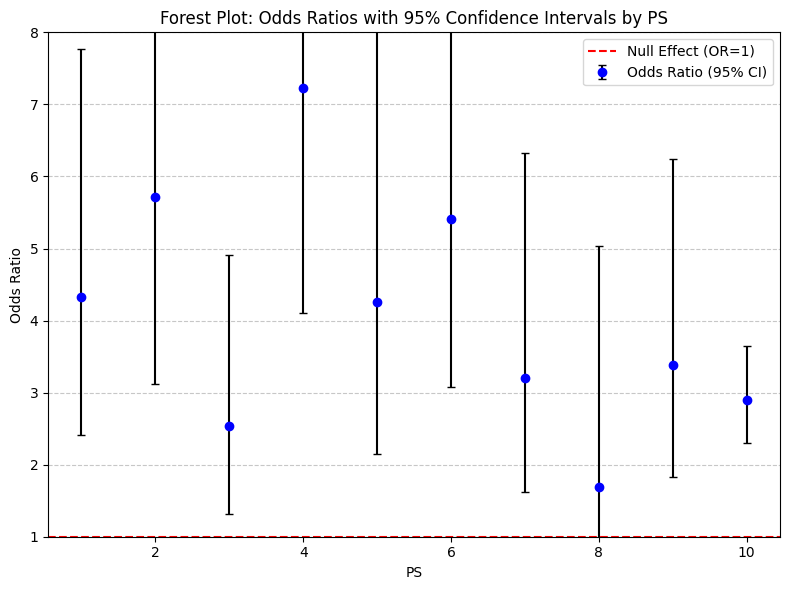

In [30]:
import matplotlib.pyplot as plt

PS = combined_enrich_4["datasource"]  
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]

# Create the horizontal forest plot
plt.figure(figsize=(8, 6))
plt.errorbar(PS, odds_ratios, yerr=[odds_ratios - ci_low, ci_high - odds_ratios], 
             fmt='o', color='blue', ecolor='black', capsize=3, 
             label="Odds Ratio (95% CI)")

# Add labels and title
plt.axhline(y=1, color='red', linestyle='--', label="Null Effect (OR=1)")
plt.xlabel("PS")
plt.ylabel("Odds Ratio")
plt.title("Forest Plot: Odds Ratios with 95% Confidence Intervals by PS")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(1, 8)
# Show the plot
plt.tight_layout()
plt.show()

In [31]:
import pandas as pd
all_enrich = []
ps_priv=1
for ps_score in range(1, 11):
    if ps_score==1:
        PSs_filtered = PSs.filter(f.col("uniqueDiseases") <= 2).select("geneId").distinct()
    elif ps_score==10:
        PSs_filtered = PSs.filter(f.col("uniqueDiseases") >= 9).select("geneId").distinct()
    else:
        PSs_filtered = PSs.filter((f.col("uniqueDiseases") >= (ps_priv))&(f.col("uniqueDiseases") <= (ps_score+1))).select("geneId").distinct()
        ps_priv = ps_score

    evidence=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=l2g_full.join(PSs_filtered, "geneId","inner").drop("diseaseIds"),
        score_column="score",
        datasource_id="l2g",
        study_locus=sl,
        study_index=si,
        min_score=0.1
    )

    enrich=chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"]
    )
    enrich["datasource"] = ps_score
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)

In [32]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)

In [33]:
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]

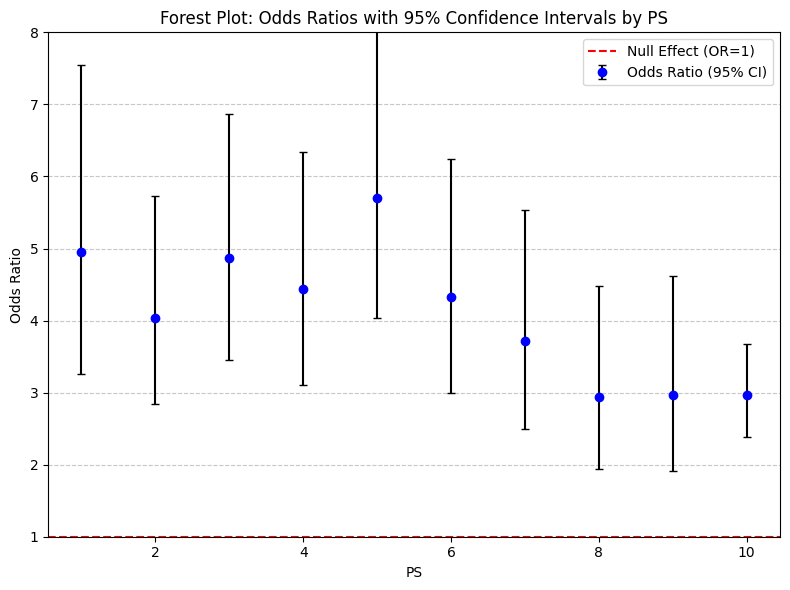

In [34]:
import matplotlib.pyplot as plt

PS = combined_enrich_4["datasource"]  
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]

# Create the horizontal forest plot
plt.figure(figsize=(8, 6))
plt.errorbar(PS, odds_ratios, yerr=[odds_ratios - ci_low, ci_high - odds_ratios], 
             fmt='o', color='blue', ecolor='black', capsize=3, 
             label="Odds Ratio (95% CI)")

# Add labels and title
plt.axhline(y=1, color='red', linestyle='--', label="Null Effect (OR=1)")
plt.xlabel("PS")
plt.ylabel("Odds Ratio")
plt.title("Forest Plot: Odds Ratios with 95% Confidence Intervals by PS")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(1, 8)
# Show the plot
plt.tight_layout()
plt.show()

In [38]:
# First, create N quantile-based bins for sum_weighted_sum_beta_variant
from pyspark.sql.window import Window

N=10

# Cast to numeric and create bins
PSs_with_bins = PSs.withColumn("sum_weighted_sum_beta_variant", f.col("sum_weighted_sum_beta_variant").cast("double"))

PSs_with_bins = PSs_with_bins.withColumn(
    "fs_bin",
    f.ntile(N).over(Window.orderBy("sum_weighted_sum_beta_variant"))
).cache()

# Check the distribution of bins
PSs_with_bins.groupBy("fs_bin").agg(
    f.count("*").alias("count"),
    f.min("sum_weighted_sum_beta_variant").alias("min_fs"),
    f.max("sum_weighted_sum_beta_variant").alias("max_fs"),
    f.avg("sum_weighted_sum_beta_variant").alias("avg_fs")
).orderBy("fs_bin").show()

# Now run the enrichment analysis for each bin
import pandas as pd
all_enrich = []

for bin_number in range(1, N+1):  # N bins: 1, 2, ..., N
    print(f"Processing FS bin: {bin_number}")
    
    # Filter genes by bin
    PSs_filtered = PSs_with_bins.filter(f.col("fs_bin") == bin_number).select("geneId").distinct()
    
    # Check how many genes in this bin
    gene_count = PSs_filtered.count()
    print(f"Genes in FS bin {bin_number}: {gene_count}")
    
    if gene_count > 0:
        evidence = chemblDrugEnrichment.to_disease_target_evidence(
            table_with_score=l2g_full.join(PSs_filtered, "geneId", "inner").drop("diseaseIds"),
            score_column="score",
            datasource_id="l2g",
            study_locus=sl,
            study_index=si,
            min_score=0.1
        )

        enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
            evid=evidence,
            disease_index_orig=disease_index_orig,
            chembl_orig=chembl_evidence,
            indirect_assoc_score_thr=0.1,
            efo_ancestors_to_remove=["MONDO_0045024"]
        )
        
        enrich["datasource"] = bin_number  # FS bin number
        enrich["drugsource"] = "full_chembl"
        enrich["metric"] = "fitness_score"  # Add identifier for the metric used

        all_enrich.append(enrich)
    else:
        print(f"No genes found for FS bin {bin_number}")

25/10/14 12:36:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/14 12:36:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/14 12:36:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/14 12:36:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/14 12:36:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/14 12:36:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/14 1

+------+-----+--------------------+--------------------+--------------------+
|fs_bin|count|              min_fs|              max_fs|              avg_fs|
+------+-----+--------------------+--------------------+--------------------+
|     1|  829|3.839875953476589E-4| 0.02303870984031729|0.014576170204950887|
|     2|  829|0.023049364341125308|0.041315508087164984| 0.03152036827262308|
|     3|  829|0.041327178391710906| 0.06801695946819644| 0.05362824505910734|
|     4|  829| 0.06812646267237733| 0.10457312210690943| 0.08554241987535217|
|     5|  829| 0.10458666036594914|  0.1687292318837626|  0.1356643651097074|
|     6|  828|  0.1689331597109332|  0.2625874750227339| 0.21322398223463276|
|     7|  828| 0.26315204964460964| 0.41131839974923484| 0.33065010530855876|
|     8|  828| 0.41133512853897364|  0.6572870024816135|   0.523268013654586|
|     9|  828|  0.6576721675443048|   1.295519781613881|  0.9073589664137035|
|    10|  828|   1.297083154079094|   42.64108790161433|  3.4083

Processing FS bin: 2
Genes in FS bin 2: 829


Processing FS bin: 3
Genes in FS bin 3: 829


Processing FS bin: 4
Genes in FS bin 4: 829


Processing FS bin: 5
Genes in FS bin 5: 829


Processing FS bin: 6
Genes in FS bin 6: 828


Processing FS bin: 7
Genes in FS bin 7: 828


Processing FS bin: 8
Genes in FS bin 8: 828


Processing FS bin: 9
Genes in FS bin 9: 828


Processing FS bin: 10
Genes in FS bin 10: 828


In [39]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]

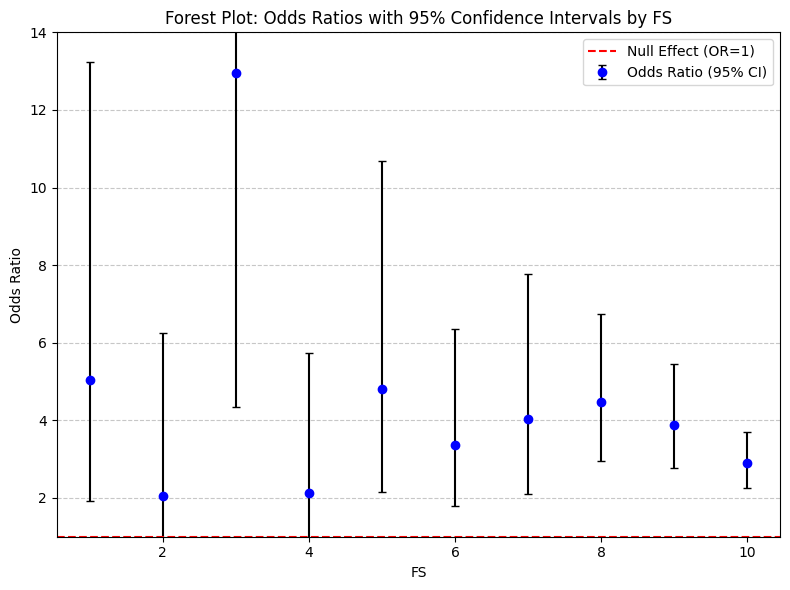

In [43]:
import matplotlib.pyplot as plt

FS = combined_enrich_4["datasource"]  
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]

# Create the horizontal forest plot
plt.figure(figsize=(8, 6))
plt.errorbar(FS, odds_ratios, yerr=[odds_ratios - ci_low, ci_high - odds_ratios], 
             fmt='o', color='blue', ecolor='black', capsize=3, 
             label="Odds Ratio (95% CI)")

# Add labels and title
plt.axhline(y=1, color='red', linestyle='--', label="Null Effect (OR=1)")
plt.xlabel("FS")
plt.ylabel("Odds Ratio")
plt.title("Forest Plot: Odds Ratios with 95% Confidence Intervals by FS")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(1, 14)
# Show the plot
plt.tight_layout()
plt.show()

In [46]:
# First, create N quantile-based bins for sum_weighted_sum_beta_variant
from pyspark.sql.window import Window

N=10

# Cast to numeric and create bins
PSs_with_bins = PSs.withColumn("inter", f.lit(f.col("sum_weighted_sum_beta_variant")*f.col("uniqueDiseases")).cast("double"))

PSs_with_bins = PSs_with_bins.withColumn(
    "fs_bin",
    f.ntile(N).over(Window.orderBy("inter"))
).cache()

# Check the distribution of bins
PSs_with_bins.groupBy("fs_bin").agg(
    f.count("*").alias("count"),
    f.min("inter").alias("min_inter"),
    f.max("inter").alias("max_inter"),
    f.avg("inter").alias("avg_inter")
).orderBy("fs_bin").show()

# Now run the enrichment analysis for each bin
import pandas as pd
all_enrich = []

for bin_number in range(1, N+1):  # N bins: 1, 2, ..., N
    print(f"Processing FS bin: {bin_number}")
    
    # Filter genes by bin
    PSs_filtered = PSs_with_bins.filter(f.col("fs_bin") == bin_number).select("geneId").distinct()
    
    # Check how many genes in this bin
    gene_count = PSs_filtered.count()
    print(f"Genes in FS bin {bin_number}: {gene_count}")
    
    if gene_count > 0:
        evidence = chemblDrugEnrichment.to_disease_target_evidence(
            table_with_score=l2g_full.join(PSs_filtered, "geneId", "inner").drop("diseaseIds"),
            score_column="score",
            datasource_id="l2g",
            study_locus=sl,
            study_index=si,
            min_score=0.1
        )

        enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
            evid=evidence,
            disease_index_orig=disease_index_orig,
            chembl_orig=chembl_evidence,
            indirect_assoc_score_thr=0.1,
            efo_ancestors_to_remove=["MONDO_0045024"]
        )
        
        enrich["datasource"] = bin_number  # FS bin number
        enrich["drugsource"] = "full_chembl"
        enrich["metric"] = "fitness_score"  # Add identifier for the metric used

        all_enrich.append(enrich)
    else:
        print(f"No genes found for FS bin {bin_number}")

25/10/14 12:49:37 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/14 12:49:37 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/14 12:49:37 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/14 12:49:37 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/14 12:49:37 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/14 12:49:37 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/14 1

+------+-----+--------------------+--------------------+--------------------+
|fs_bin|count|           min_inter|           max_inter|           avg_inter|
+------+-----+--------------------+--------------------+--------------------+
|     1|  829|7.378431249851873E-4|0.023821445955013926|0.014817066248280936|
|     2|  829|0.023838330765040334| 0.04981423512971929|0.035155669295858546|
|     3|  829|0.049840861475823256| 0.09769917467101669| 0.07196052199582086|
|     4|  829| 0.09780390193777337| 0.20090471485908482| 0.14447226901832583|
|     5|  829|  0.2012006467709273|  0.3870272461831984|  0.2860643069914037|
|     6|  828|  0.3873388932442867|  0.7139579909961824|  0.5318891519314831|
|     7|  828|  0.7147448410897568|  1.4557657283915526|  1.0396364873138946|
|     8|  828|  1.4582212451526266|  3.3246991671499107|  2.2512662694793004|
|     9|  828|   3.324827888464458|  10.919893450127422|   6.116311348822567|
|    10|  828|  10.943480396014627|   4593.592924039602|   86.45

Processing FS bin: 2
Genes in FS bin 2: 829


Processing FS bin: 3
Genes in FS bin 3: 829


Processing FS bin: 4
Genes in FS bin 4: 829


Processing FS bin: 5
Genes in FS bin 5: 829


Processing FS bin: 6
Genes in FS bin 6: 828


Processing FS bin: 7
Genes in FS bin 7: 828


Processing FS bin: 8
Genes in FS bin 8: 828


Processing FS bin: 9
Genes in FS bin 9: 828


Processing FS bin: 10
Genes in FS bin 10: 828


In [47]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]

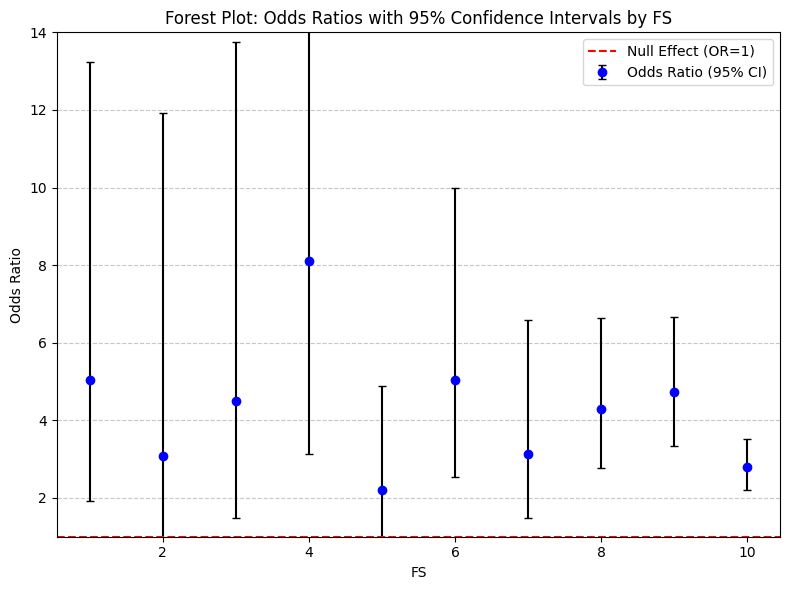

25/10/14 19:47:38 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 929811 ms exceeds timeout 120000 ms
25/10/14 19:47:38 WARN SparkContext: Killing executors is not supported by current scheduler.
25/10/14 19:47:47 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [48]:
import matplotlib.pyplot as plt

FS = combined_enrich_4["datasource"]  
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]

# Create the horizontal forest plot
plt.figure(figsize=(8, 6))
plt.errorbar(FS, odds_ratios, yerr=[odds_ratios - ci_low, ci_high - odds_ratios], 
             fmt='o', color='blue', ecolor='black', capsize=3, 
             label="Odds Ratio (95% CI)")

# Add labels and title
plt.axhline(y=1, color='red', linestyle='--', label="Null Effect (OR=1)")
plt.xlabel("FS")
plt.ylabel("Odds Ratio")
plt.title("Forest Plot: Odds Ratios with 95% Confidence Intervals by FS")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(1, 14)
# Show the plot
plt.tight_layout()
plt.show()